In [56]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from palettable.colorbrewer.sequential import Oranges_9, YlGn_9
from matplotlib.patches import Patch
import contextily as cx

from lonboard import Map, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [57]:
df = pd.read_csv("./Data/Active_Sheds2.csv")  # read csv file

In [58]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["Longitude Point"], df["Latitude Point"]
    ),  # extract from csv file
    crs="EPSG:4326",  # set coordinate reference system
)

gdf.to_file("sheds.fgb", driver="FlatGeobuf")  # convert to fgb file

In [ ]:
sheds_data = gpd.read_file("sheds.fgb")  # convert to fgb file

In [60]:
sheds_data.head()

,Job Number,Borough Name,Count Permits,First Permit Date,Current Date,Age,Permit Expiration Date,Sidewalk Shed/Linear Feet,Construction Material,Current Job Status,...,Borough Digit,Block,Lot,Applicant Business Name,ProCert,Source,activity,Commercial,CouncilDistrict,geometry
0,Q01090694-I1,Queens,NaN,8/5/2024,8/5/2026,729,10/7/2026,2170.0,NaN,Permit Entire,...,4,15610,1,MJE PROFESSIONAL SERVICES,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.74192 40.59533)
1,Q01004677-I1,Queens,NaN,2/28/2024,8/5/2026,888,9/29/2026,398.0,NaN,Permit Entire,...,4,15810,30,Always Fast Services Corp,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.75384 40.59477)
2,Q01090967-I1,Queens,NaN,8/5/2024,8/5/2026,729,9/29/2026,233.0,NaN,Permit Entire,...,4,15810,25,Always Fast Services Corp,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.7543 40.59425)
3,Q01004680-I1,Queens,NaN,2/29/2024,8/5/2026,887,9/29/2026,208.0,NaN,Permit Entire,...,4,15810,55,Always Fast Services Corp,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.75397 40.59324)
4,Q01004679-I1,Queens,NaN,3/1/2024,8/5/2026,886,9/29/2026,190.0,NaN,Permit Entire,...,4,15810,55,Always Fast Services Corp,1,DOB NOW,Local Law 11,Other Zoning Districts,31.0,POINT (-73.75397 40.59324)


<Axes: >

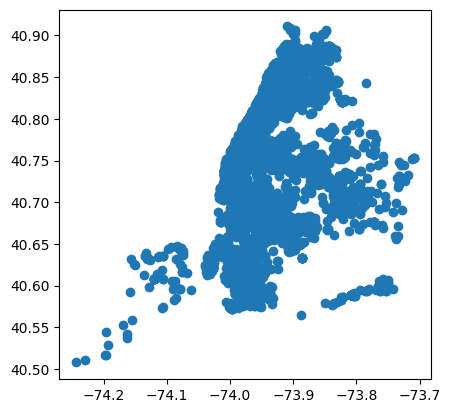

In [61]:
sheds_data.plot()  # first plot

<Axes: >

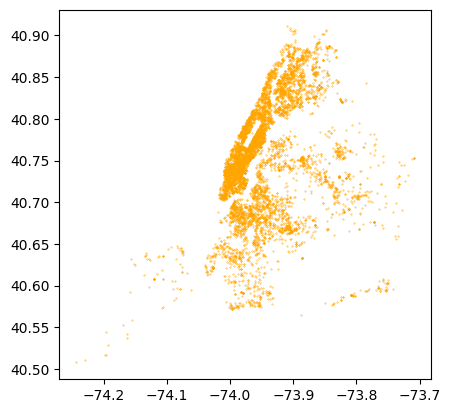

In [62]:
sheds_data.plot(
    markersize=0.1, color="orange"
)  # rescale the size of the points and change the color to orange

In [63]:
sheds_data.columns  # display the column names, trying to understand tha data structure

Index(['Job Number', 'Borough Name', 'Count Permits', 'First Permit Date',
       'Current Date', 'Age', 'Permit Expiration Date',
       'Sidewalk Shed/Linear Feet', 'Construction Material',
       'Current Job Status', 'BIN Number', 'Community Board', 'Latitude Point',
       'Longitude Point', 'House Number', 'Street Name', 'Borough Digit',
       'Block', 'Lot', 'Applicant Business Name', 'ProCert', 'Source',
       'activity', 'Commercial', 'CouncilDistrict', 'geometry'],
      dtype='str')

In [64]:
sheds_data[
    "Borough Name"
].describe()  # display the summary statistics of the Shed Area column

count          7519
unique            5
top       Manhattan
freq           3402
Name: Borough Name, dtype: object

<Axes: >

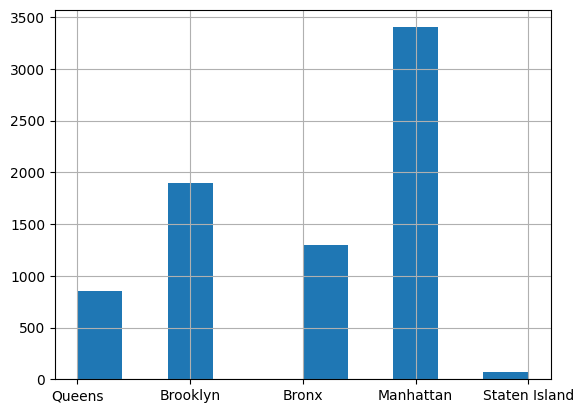

In [68]:
sheds_data[
    "Borough Name"
].hist()  # display the summary statistics of the Shed Area column

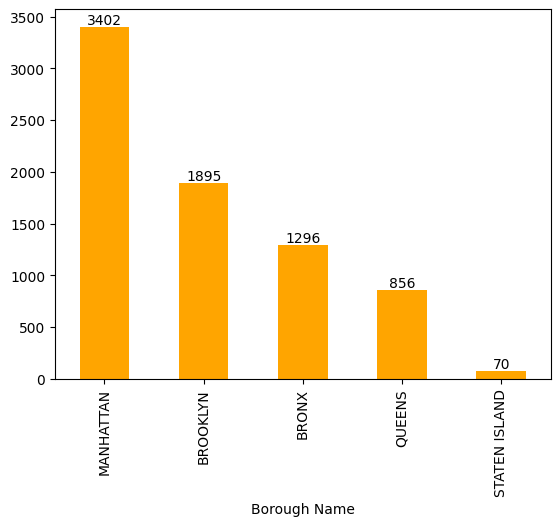

In [70]:
counts = (
    sheds_data["Borough Name"].str.upper().value_counts()
)  # count sidewalk sheds per borough
ax = counts.plot(kind="bar", color="orange")  # plot the counts as a bar chart
ax.bar_label(ax.containers[0])  # add the count number on top of each bar
plt.show()  # plot the chat

In [ ]:
districts = gpd.read_file(
    "./Data/geo_export_e5c4913d-d23e-47c5-ad1c-2bbe098562d8.shp"
)  # load community district boundaries
districts = districts.to_crs(sheds_data.crs)  # make sure it lines up with sheds_data's coordinates

shed_counts = (
    sheds_data["Community Board"].value_counts()
)  # count sidewalk sheds per community district code

districts["shed_count"] = districts["boro_cd"].map(shed_counts)  # attach each district's shed count by matching its code
districts["shed_count"] = districts["shed_count"].fillna(0)  # districts with zero sheds show as 0 instead of blank

ax = districts.plot(
    column="shed_count",  # fill each district based on its shed count
    cmap="Oranges",  # gradient: pale = few sheds, dark = many sheds
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    figsize=(10, 10),
)  # draw a filled-in map, one color per district, based on shed count

ax.set_title("Sidewalk Sheds per Community District", fontsize=14)  # add a title
ax.axis("off")  # hide the x/y coordinate numbers, not needed for a map

plt.show()  # display the map

In [ ]:
board_names = {
    101: "Battery Park City, Greenwich Village, Financial District, Tribeca",
    102: "Greenwich Village, SoHo, NoHo, Little Italy, Chinatown",
    103: "Lower East Side, Chinatown, East Village",
    104: "Chelsea, Clinton/Hell's Kitchen",
    105: "Midtown, Flatiron, Union Square",
    106: "Murray Hill, Gramercy, Stuyvesant Town, Turtle Bay",
    107: "Upper West Side, Lincoln Square, Manhattan Valley",
    108: "Upper East Side, Yorkville, Carnegie Hill",
    109: "Morningside Heights, Manhattanville, Hamilton Heights, West Harlem",
    110: "Central Harlem",
    111: "East Harlem",
    112: "Washington Heights, Inwood",
    201: "Mott Haven, Melrose, Port Morris",
    202: "Hunts Point, Longwood",
    203: "Morrisania, Crotona Park East",
    204: "Highbridge, Concourse Village",
    205: "Fordham, University Heights, Morris Heights",
    206: "East Tremont, Belmont, West Farms",
    207: "Kingsbridge Heights, Bedford Park, Norwood",
    208: "Riverdale, Fieldston, Kingsbridge",
    209: "Soundview, Parkchester, Castle Hill",
    210: "Throgs Neck, Co-op City, Pelham Bay",
    211: "Morris Park, Pelham Parkway, Laconia",
    212: "Williamsbridge, Baychester, Wakefield",
    301: "Greenpoint, Williamsburg",
    302: "Fort Greene, Clinton Hill",
    303: "Bedford-Stuyvesant",
    304: "Bushwick",
    305: "East New York, Starrett City, Cypress Hills",
    306: "Park Slope, Carroll Gardens, Red Hook, Cobble Hill",
    307: "Sunset Park, Windsor Terrace",
    308: "Crown Heights North, Prospect Heights",
    309: "Crown Heights South, Wingate, Lefferts Gardens",
    310: "Bay Ridge, Dyker Heights, Fort Hamilton",
    311: "Bensonhurst, Bath Beach",
    312: "Borough Park, Kensington, Ocean Parkway",
    313: "Coney Island, Brighton Beach, Sea Gate",
    314: "Flatbush, Midwood",
    315: "Sheepshead Bay, Gerritsen Beach, Manhattan Beach",
    316: "Brownsville, Ocean Hill",
    317: "East Flatbush, Rugby, Farragut",
    318: "Canarsie, Flatlands",
    401: "Astoria, Long Island City",
    402: "Sunnyside, Woodside",
    403: "Jackson Heights, East Elmhurst",
    404: "Elmhurst, Corona",
    405: "Ridgewood, Glendale, Maspeth, Middle Village",
    406: "Rego Park, Forest Hills",
    407: "Flushing, Murray Hill, Whitestone",
    408: "Fresh Meadows, Briarwood, Hillcrest, Jamaica Hills",
    409: "Kew Gardens, Richmond Hill, Woodhaven",
    410: "South Ozone Park, Ozone Park, Howard Beach",
    411: "Bayside, Douglaston, Little Neck",
    412: "Jamaica, St. Albans, Hollis",
    413: "Queens Village, Cambria Heights, Bellerose",
    414: "Rockaway, Broad Channel, Far Rockaway",
    501: "St. George, Stapleton, Port Richmond",
    502: "South Beach, Willowbrook, New Dorp",
    503: "Tottenville, Great Kills, Annadale",
}  # community board code -> associated neighborhoods (NYC Planning)

df["Community Board Name"] = df["Community Board"].map(
    lambda code: board_names.get(int(code), f"Unknown/Park ({int(code)})")
)  # new column: neighborhood name for each row, based on its Community Board code

In [ ]:
df["First Permit Date"] = pd.to_datetime(
    df["First Permit Date"]
)  # convert text dates to real datetime values
df["Permit Expiration Date"] = pd.to_datetime(
    df["Permit Expiration Date"]
)  # same for the expiration date

df["Permit Days"] = (
    df["Permit Expiration Date"] - df["First Permit Date"]
).dt.days  # new column: how many days between the permit starting and expiring

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude Point"], df["Latitude Point"]),
    crs="EPSG:4326",
)  # rebuild the geometry from the updated df, now with "Community Board Name" and "Permit Days"
gdf.to_file("sheds2.fgb", driver="FlatGeobuf")  # rebuild sheds2.fgb so it includes the new columns
sheds_data = gpd.read_file("sheds2.fgb")  # reload sheds_data from the SAME file just written

sheds_data = sheds_data[
    sheds_data["Community Board"].isin(board_names.keys())
]  # drop parks/airports/etc. (codes like 164, 355, 481) so every chart below uses real districts only

sheds_data.columns  # confirm both new columns made it in

In [ ]:
top10_counts = (
    sheds_data["Community Board Name"].value_counts().head(10)
)  # count sidewalk sheds per neighborhood, keep only the top 10
top10_counts

In [ ]:
top10_days = (
    sheds_data.groupby("Community Board Name")["Permit Days"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)  # average permit duration per neighborhood, top 10 longest
top10_days

In [ ]:
common = set(top10_counts.index) & set(top10_days.index)  # neighborhoods that appear in BOTH top 10 lists

overlap = pd.DataFrame({
    "Shed Count": top10_counts.reindex(common),
    "Avg Permit Days": top10_days.reindex(common),
}).sort_values("Shed Count", ascending=False)  # combine both rankings for just the overlapping neighborhoods
overlap

In [ ]:
from matplotlib.lines import Line2D

top10_names = top10_days.index  # the 10 neighborhood names from the average-permit-days ranking
subset = sheds_data[sheds_data["Community Board Name"].isin(top10_names)]  # keep only sheds in those 10 neighborhoods

ax = subset.boxplot(column="Permit Days", by="Community Board Name", figsize=(12, 6))
plt.title("Permit Duration Distribution — Top 10 Neighborhoods by Avg. Permit Days")
plt.suptitle("")  # removes pandas' default auto-title
plt.ylabel("Permit Days")
plt.xticks(rotation=45, ha="right")

means = subset.groupby("Community Board Name")["Permit Days"].mean().reindex(top10_names)  # average per neighborhood
plt.scatter(
    range(1, len(means) + 1), means.values, color="red", marker="D", zorder=3
)  # plot the average as a red diamond on each box, so it's visible against the median/outliers

legend_elements = [
    Line2D([0], [0], color="orange", lw=2, label="Median"),
    Patch(facecolor="white", edgecolor="black", label="IQR (middle 50% of permits)"),
    Line2D([0], [0], color="black", lw=1, linestyle="--", label="Whiskers (typical range)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markeredgecolor="black", label="Outliers"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="red", markeredgecolor="red", label="Mean"),
]  # manually built legend entries explaining each part of the box plot
plt.legend(handles=legend_elements, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
shed_feet_per_district = (
    sheds_data.groupby(["Community Board", "Community Board Name"])[
        "Sidewalk Shed/Linear Feet"
    ]
    .sum()
    .reset_index()
)  # total shed feet per district, with both the code and the name
# (parks/airports already filtered out upstream, in the sheds_data rebuild cell)

lots = gpd.read_file("./Data/MapPLUTO_UNCLIPPED.shp")  # NYC tax lot polygons
lots = lots.to_crs(
    "EPSG:2263"
)  # NY State Plane (feet) so measurements come out in feet

sidewalk_length_per_district = lots.groupby("CD")[
    "LotFront"
].sum()  # total street frontage (feet) of all tax lots in each community district

combined = shed_feet_per_district.copy()
combined["Total Sidewalk Length (ft)"] = combined["Community Board"].map(
    sidewalk_length_per_district
)  # pull in each district's total sidewalk length from MapPLUTO

combined = combined.rename(
    columns={"Sidewalk Shed/Linear Feet": "Total Shed Length (ft)"}
)  # clearer column name for the table

combined["% Covered"] = (
    combined["Total Shed Length (ft)"] / combined["Total Sidewalk Length (ft)"] * 100
).clip(
    upper=100
)  # what share of the district's sidewalk is shedded

combined = combined.sort_values("% Covered", ascending=False)  # highest coverage first
combined

In [ ]:
top10_covered = combined.head(10)  # 10 districts with the highest % of sidewalk covered by sheds
top10_covered